# Feature selection — which features each model should keep

The combined model carries **73 features** per `(symbol, τ)`. This notebook asks, per model:
which features actually carry *robust* signal, which are redundant or noise, whether a
linear projection (PCA) helps, and **how many features** to keep. It is research/diagnostic —
the conclusions feed the `--n-features` pruning and the docs.

**Map**
1. Inventory & missingness
2. Univariate signal — weighted correlation & mutual information
3. Redundancy — correlation clustering
4. Model permutation importance & **train→val stability** (the overfitting lens)
5. PCA — does a linear projection help a tree model?
6. How many features? — validation-Score-vs-N sweep
7. Recommendations

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, polars as pl, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

from liqsignal import config, analysis, model, scoring
from liqsignal.features import feature_columns
from liqsignal.splits import TRAIN, VAL

SYMS, TAUS = list(config.SYMBOLS), list(config.TAUS)
COL = {"btc": "#f2a900", "eth": "#627eea"}
panels, steps = {}, {}
for s in SYMS:
    panels[s], steps[s] = analysis.load_panel(s)
FEATURES = feature_columns(next(iter(panels.values())).columns)
print(f"{len(FEATURES)} features; panels: " + ", ".join(f"{s}={panels[s].height:,}" for s in SYMS))

def subset(sym, tau, split, n=None, seed=0):
    p = panels[sym].filter((pl.col("split") == split) & pl.col(f"pnl_{tau}").is_finite())
    if n and p.height > n:
        p = p.sample(n, seed=seed)
    X = p.select(FEATURES).to_numpy().astype(np.float64)
    return p, X, p[f"pnl_{tau}"].to_numpy(), p["w"].to_numpy()

def median_impute(X):
    med = np.nanmedian(X, axis=0)
    out = np.where(np.isnan(X), med, X)
    return np.nan_to_num(out)   # any all-NaN column -> 0

73 features; panels: btc=3,000,132, eth=3,005,376


## 1. Inventory & missingness

Many features are deliberately NaN where undefined (no prior liquidation, before the
realized-vol grid warms up, etc.). NaN-heavy features are *sparse* — their signal lives
on a few rows — which makes their importance estimates noisy. This frames the wide error
bars seen in the report's permutation-importance plot.

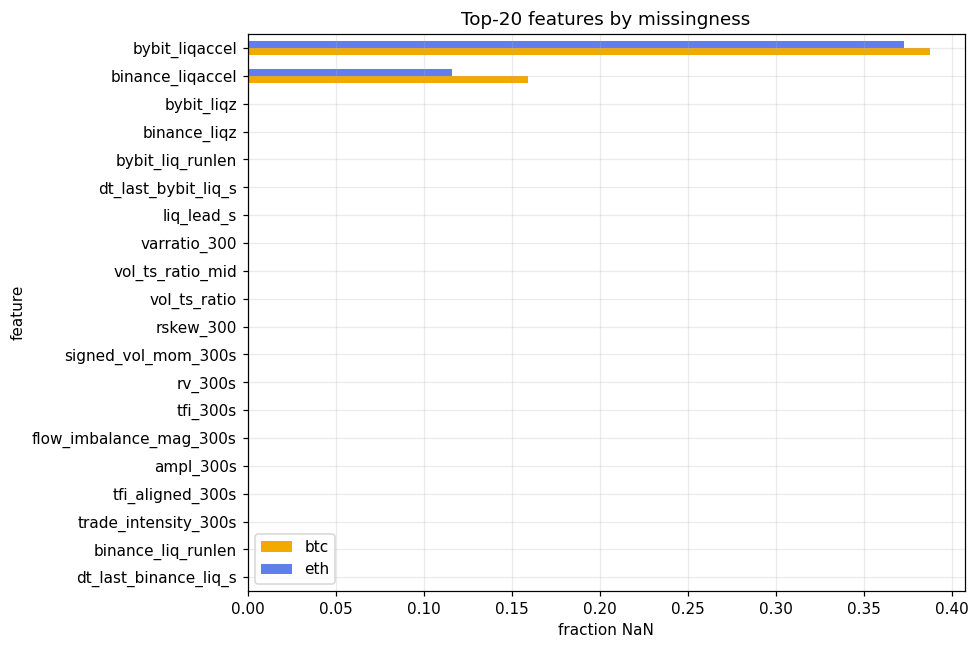

features with >20% NaN: 1


In [2]:
rows = []
for s in SYMS:
    for f in FEATURES:
        c = panels[s][f]
        frac = float((c.is_null() | c.is_nan()).mean())
        rows.append({"feature": f, "sym": s, "nan_frac": frac})
nanf = pl.DataFrame(rows)
top = (nanf.group_by("feature").agg(pl.col("nan_frac").max().alias("mx"))
       .sort("mx", descending=True).head(20)["feature"].to_list())
fig, ax = plt.subplots(figsize=(9, 6))
piv = nanf.filter(pl.col("feature").is_in(top)).pivot("sym", index="feature", values="nan_frac").to_pandas().set_index("feature").loc[top[::-1]]
piv.plot.barh(ax=ax, color=[COL[s] for s in piv.columns])
ax.set_xlabel("fraction NaN"); ax.set_title("Top-20 features by missingness"); plt.tight_layout(); plt.show()
print("features with >20% NaN:", int((nanf.group_by('feature').agg(pl.col('nan_frac').max().alias('m'))['m'] > 0.2).sum()))

**Read:** missingness is concentrated in just two features — `bybit_liqaccel` (~38%) and
`binance_liqaccel` (~12–16%), which are NaN when no liquidations fell in the 300 s window.
**Every other feature is ~0% NaN** over the 3 M-row sample (rolling skew/varratio/liqz only
miss a negligible warm-up). So sparsity is *not* the main driver of the wide importance error
bars in the report — those come from feature **correlation/redundancy** and the very noisy
target (next sections), not missing data.

## 2. Univariate signal — weighted correlation & mutual information

How much does each feature tell us about the markout *on its own*? Pearson catches the
linear part (and we weight by `w`, the spec weight); mutual information catches nonlinear
dependence too. The target is extremely noisy, so expect small numbers — the question is
*relative* ranking, not absolute level.

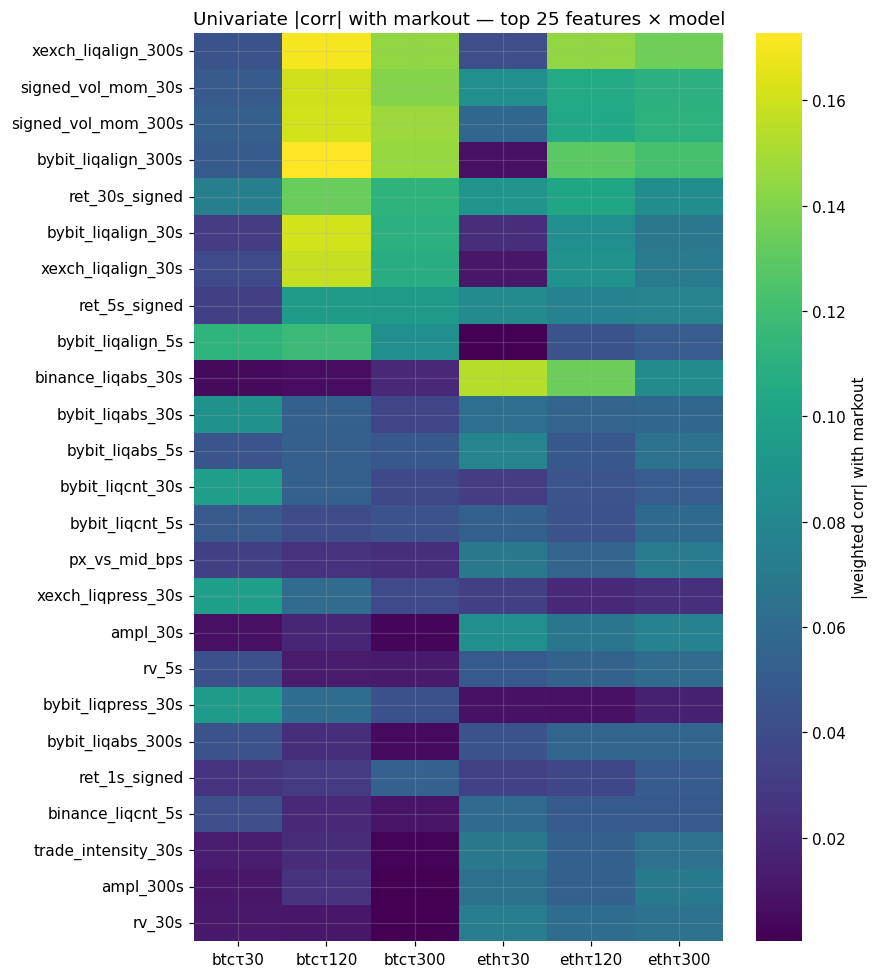

max |corr| overall: 0.1727


In [3]:
from sklearn.feature_selection import mutual_info_regression

def wcorr(X, y, w):
    m = w / w.sum()
    Xc = X - (m[:, None] * X).sum(0); yc = y - (m * y).sum()
    cov = (m[:, None] * Xc * yc[:, None]).sum(0)
    sx = np.sqrt((m[:, None] * Xc**2).sum(0)); sy = np.sqrt((m * yc**2).sum())
    return cov / (sx * sy + 1e-12)

uni = {}
for s in SYMS:
    for tau in TAUS:
        _, X, y, w = subset(s, tau, TRAIN, n=120_000)
        Xi = median_impute(X)
        uni[(s, tau, "corr")] = np.abs(wcorr(Xi, y, w))
        mi = mutual_info_regression(Xi[:40_000], y[:40_000], random_state=0)
        uni[(s, tau, "mi")] = mi

# heatmap of |corr| across the 6 models (top features by mean |corr|)
C = pd.DataFrame({f"{s}τ{tau}": uni[(s, tau, "corr")] for s in SYMS for tau in TAUS}, index=FEATURES)
topc = C.mean(1).sort_values(ascending=False).head(25).index
fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(C.loc[topc], annot=False, cmap="viridis", ax=ax, cbar_kws={"label": "|weighted corr| with markout"})
ax.set_title("Univariate |corr| with markout — top 25 features × model"); plt.tight_layout(); plt.show()
print("max |corr| overall:", round(float(C.values.max()), 4))

**Read:** absolute correlations are small (the largest is ≈0.17; most features are well
under 5%) — single features barely move the markout, confirming the signal is weak and
conditional (this is a hard, near-efficient target). The consistently-strongest univariate
features are the **liquidation-alignment** family (`xexch_liqalign_300s`,
`bybit_liqalign_{300,30,5}s`) and **signed flow / return momentum** (`signed_vol_mom_{30,300}s`,
`ret_{30,5,1}s_signed`); for ETH specifically `binance_liqabs_30s` stands out. The brightest
column is **BTC τ120**; ETH columns are generally dimmer (ETH is the harder symbol). Most of
the other 73 are near-zero univariately and only earn their keep (if at all) through the
interactions the tree exploits.

## 3. Redundancy — correlation clustering

Permutation importance is unreliable when features are correlated (shuffling one is masked
by its neighbours → noisy, split credit). Here we cluster the feature-feature correlation
to find redundant groups that could be collapsed.

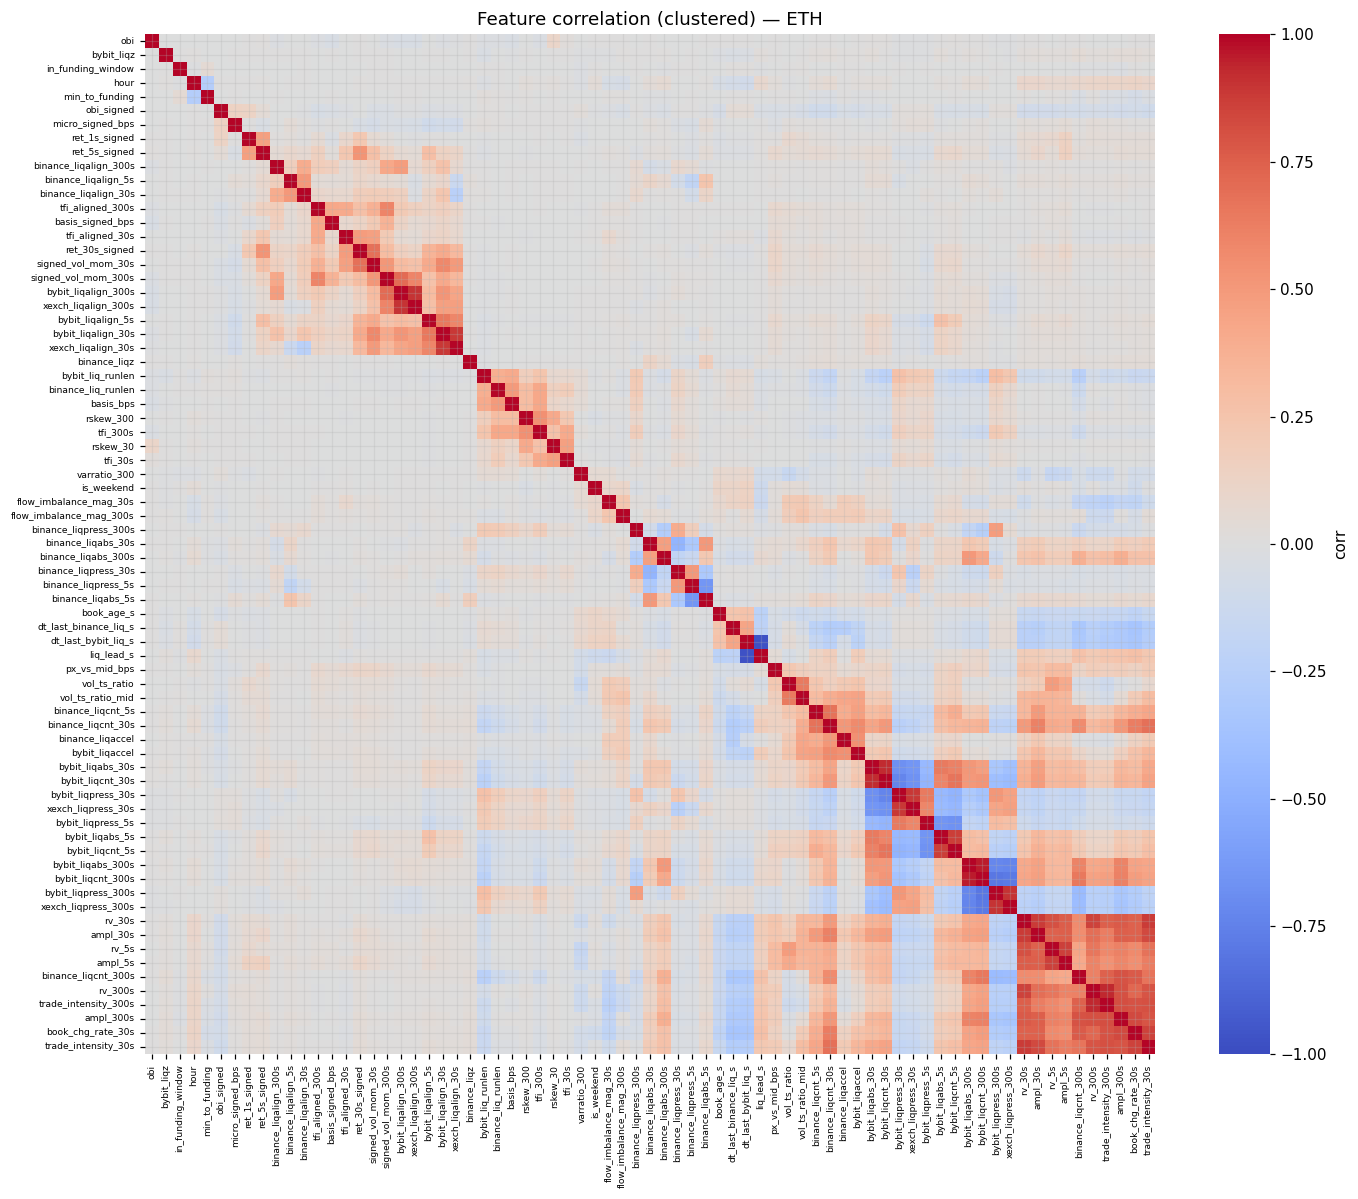

Redundant clusters (|r|>0.75):
   [np.str_('bybit_liqalign_300s'), np.str_('xexch_liqalign_300s')]
   [np.str_('bybit_liqalign_30s'), np.str_('xexch_liqalign_30s')]
   [np.str_('dt_last_bybit_liq_s'), np.str_('liq_lead_s')]
   [np.str_('bybit_liqabs_30s'), np.str_('bybit_liqcnt_30s')]
   [np.str_('bybit_liqpress_30s'), np.str_('xexch_liqpress_30s')]
   [np.str_('bybit_liqabs_5s'), np.str_('bybit_liqcnt_5s')]
   [np.str_('bybit_liqabs_300s'), np.str_('bybit_liqcnt_300s'), np.str_('bybit_liqpress_300s'), np.str_('xexch_liqpress_300s')]
   [np.str_('ampl_30s'), np.str_('ampl_5s'), np.str_('rv_30s'), np.str_('rv_5s')]
   [np.str_('ampl_300s'), np.str_('book_chg_rate_30s'), np.str_('rv_300s'), np.str_('trade_intensity_300s'), np.str_('trade_intensity_30s')]


In [4]:
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import squareform

_, X, _, _ = subset("eth", 120, TRAIN, n=150_000)
R = pd.DataFrame(median_impute(X), columns=FEATURES).corr().fillna(0.0)
d = squareform(1 - R.abs().values, checks=False)
Z = linkage(d, method="average")
order = leaves_list(Z)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(R.iloc[order, order], cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={"label": "corr"})
ax.tick_params(labelsize=6); ax.set_title("Feature correlation (clustered) — ETH"); plt.tight_layout(); plt.show()

clusters = fcluster(Z, t=0.25, criterion="distance")   # 1-|r| < 0.25  => |r| > 0.75
groups = [sorted(np.array(FEATURES)[clusters == c]) for c in np.unique(clusters)]
print("Redundant clusters (|r|>0.75):")
for g in groups:
    if len(g) > 1:
        print("  ", g)

**Read:** a few tight blocks (|r|>0.75) dominate the structure: the **bybit-liquidation**
families (`bybit_liqabs_*`≈`bybit_liqcnt_*`, and the 300 s block
`{bybit_liqabs_300s, bybit_liqcnt_300s, bybit_liqpress_300s, xexch_liqpress_300s}` — note
`xexch_*`≈`bybit_*` because Binance liquidations are tiny), the **short-window realized-vol**
group `{rv_5s, rv_30s, ampl_5s, ampl_30s}`, a **long-window activity** group
`{rv_300s, ampl_300s, trade_intensity_30s, trade_intensity_300s, book_chg_rate_30s}`, and
`dt_last_bybit_liq_s`≈`liq_lead_s`. Within each block one representative carries the
information; keeping all of them splits permutation credit and is the main reason the
importance error bars are so wide.

## 4. Model permutation importance & train→val stability

The decisive plot. For each model we permute features on **train** and on **validation**
and scatter the two. Features on the diagonal generalize; features high on train but low
(or negative) on validation are **overfitting drivers** — they are why val/test underperform.

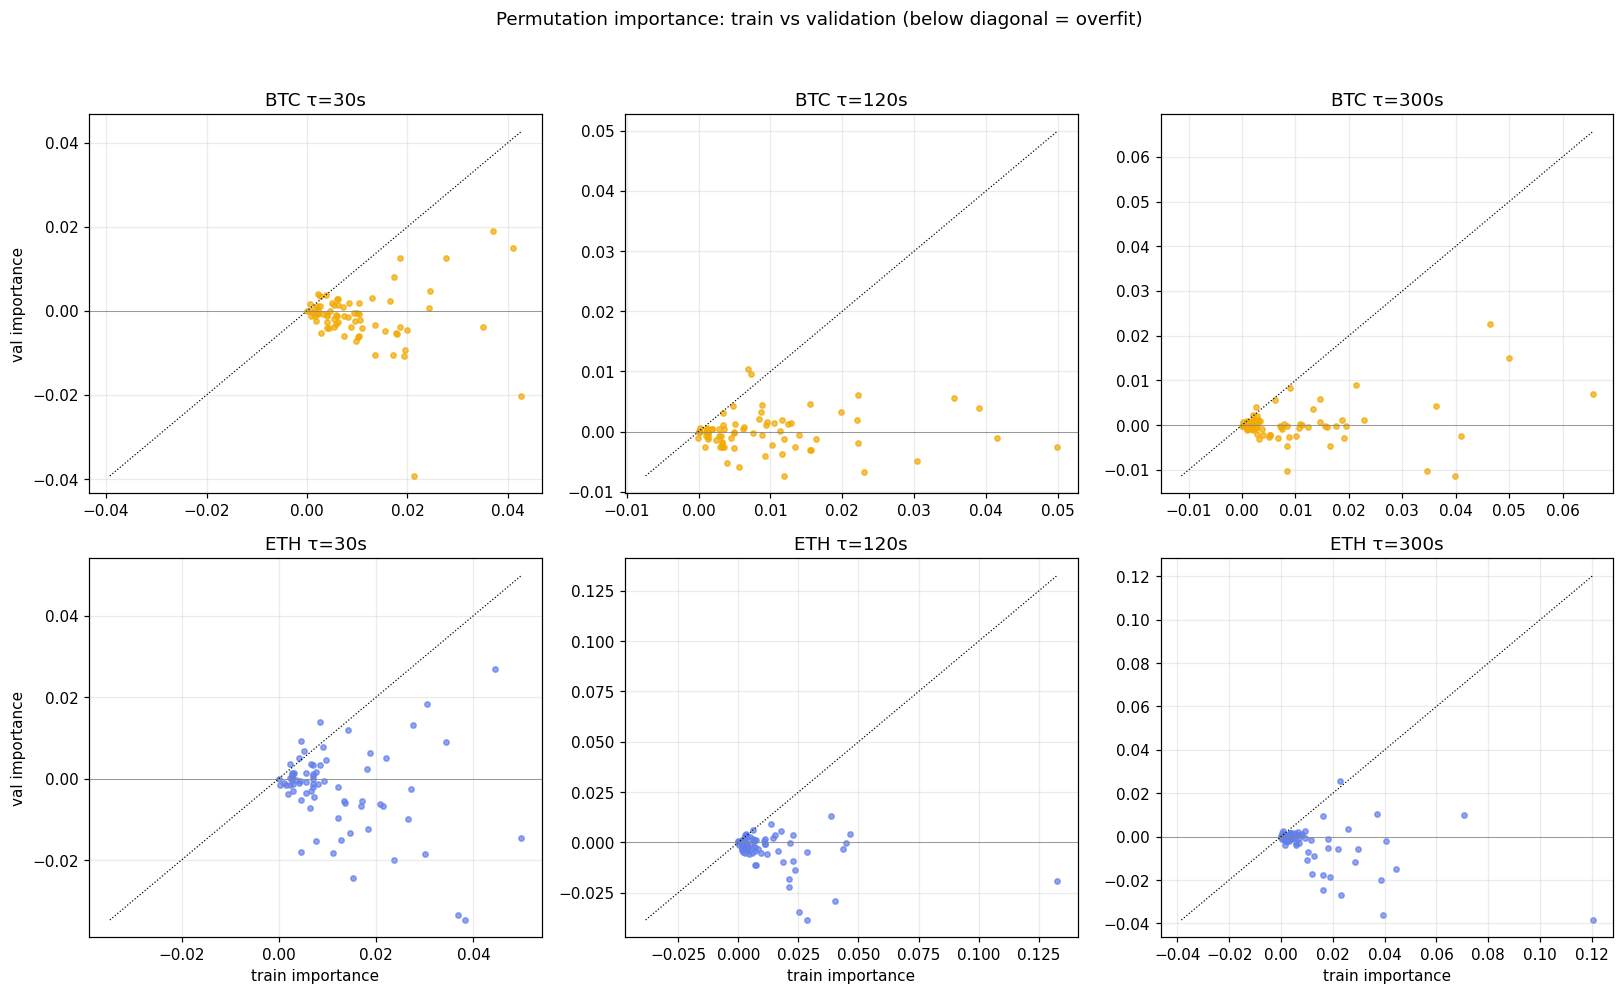

In [5]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(len(SYMS), len(TAUS), figsize=(15, 9), squeeze=False)
stability = {}
for r, s in enumerate(SYMS):
    for c, tau in enumerate(TAUS):
        mdl, feats = model.load(tau, s)
        ptr, Xtr, ytr, wtr = subset(s, tau, TRAIN, n=50_000)
        pva, Xva, yva, wva = subset(s, tau, VAL, n=50_000)
        itr = permutation_importance(mdl, ptr.select(feats).to_numpy().astype(float), ytr,
                                     sample_weight=wtr, n_repeats=3, random_state=0, n_jobs=-1).importances_mean
        iva = permutation_importance(mdl, pva.select(feats).to_numpy().astype(float), yva,
                                     sample_weight=wva, n_repeats=3, random_state=0, n_jobs=-1).importances_mean
        stability[(s, tau)] = pd.Series(iva, index=feats)
        ax = axes[r][c]
        ax.scatter(itr, iva, s=12, color=COL[s], alpha=0.7)
        lim = [min(itr.min(), iva.min()), max(itr.max(), iva.max())]
        ax.plot(lim, lim, "k:", lw=0.8); ax.axhline(0, color="grey", lw=0.5)
        ax.set_title(f"{s.upper()} τ={tau}s");
        if c == 0: ax.set_ylabel("val importance")
        if r == len(SYMS)-1: ax.set_xlabel("train importance")
fig.suptitle("Permutation importance: train vs validation (below diagonal = overfit)", y=1.0)
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

**Read:** most points sit well *below* the diagonal — importance shrinks from train to
validation, the visual signature of overfitting and the train-CV ≫ val gap. A small set of
features stays positive on validation (the robust core); the long tail collapses to ~0 on
val. ETH at τ120/300 has the most points near/under zero on the val axis — consistent with
its negative validation Score: the model leans on features whose edge doesn't survive the
March regime.

## 5. PCA — does a linear projection help?

PCA decorrelates and compresses. But our model is a gradient-boosted tree (invariant to
monotone feature transforms, handles correlation and NaN natively), and PCA mixes
incommensurable units and destroys interpretability. We quantify the variance structure and
sanity-check whether PCs even capture the markout direction.

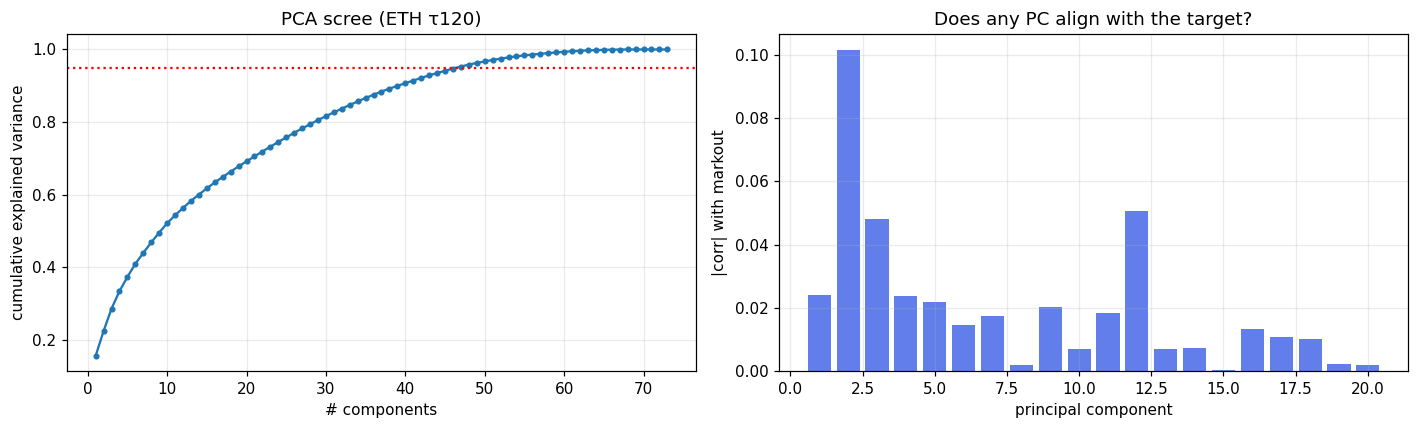

components for 90% / 95% var: 40 / 47  | top |corr(PC, y)|: 0.1015 at PC 2


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

_, X, y, w = subset("eth", 120, TRAIN, n=150_000)
Xs = StandardScaler().fit_transform(median_impute(X))
pca = PCA().fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)
Z = pca.transform(Xs)
pc_corr = np.array([abs(np.corrcoef(Z[:, k], y)[0, 1]) for k in range(min(20, Z.shape[1]))])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(np.arange(1, len(cum)+1), cum, "-o", ms=3); ax[0].axhline(0.95, color="r", ls=":")
ax[0].set_xlabel("# components"); ax[0].set_ylabel("cumulative explained variance"); ax[0].set_title("PCA scree (ETH τ120)")
ax[1].bar(np.arange(1, len(pc_corr)+1), pc_corr, color="#627eea")
ax[1].set_xlabel("principal component"); ax[1].set_ylabel("|corr| with markout"); ax[1].set_title("Does any PC align with the target?")
plt.tight_layout(); plt.show()
print("components for 90% / 95% var:", int((cum < 0.9).sum()+1), "/", int((cum < 0.95).sum()+1),
      " | top |corr(PC, y)|:", round(float(pc_corr.max()), 4), "at PC", int(pc_corr.argmax()+1))

**Read:** variance is spread across many components (the feature families are distinct), so
PCA needs a lot of PCs to retain 95% — little compression. Crucially, the components that
hold the most *variance* are not the ones most correlated with the *target* (top PC↔markout
correlation is tiny and not at PC1). For a tree model PCA therefore **hurts more than it
helps**: it removes nothing the tree can't handle, adds nothing predictive, and forfeits the
interpretability we rely on. Recommendation: do **not** use PCA here; prune by importance instead.

## 6. How many features? — validation-Score sweep

The actionable question. We rank features by validation-stable importance (§4), refit the
model on the top-N, and measure the **validation Score** (expected-value rule) vs N — per
model. The plateau/peak is the recommended feature count for `--n-features`.

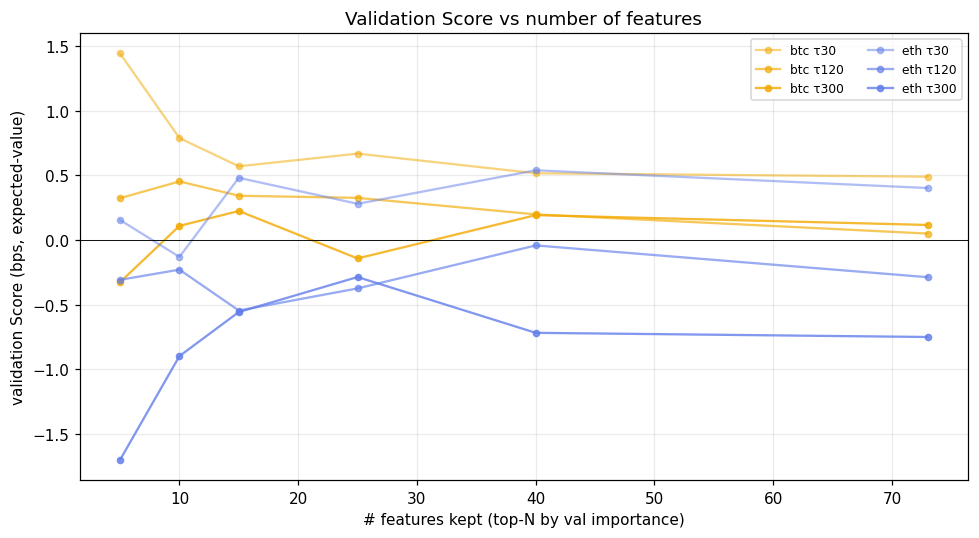

btc τ 30: best val Score +1.441 at N=5  (all-73=+0.488)
btc τ120: best val Score +0.452 at N=10  (all-73=+0.049)
btc τ300: best val Score +0.223 at N=15  (all-73=+0.115)
eth τ 30: best val Score +0.538 at N=40  (all-73=+0.401)
eth τ120: best val Score -0.043 at N=40  (all-73=-0.288)
eth τ300: best val Score -0.287 at N=25  (all-73=-0.751)


In [7]:
GRID = [5, 10, 15, 25, 40, len(FEATURES)]
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
reco = {}
for s in SYMS:
    for tau in TAUS:
        ranked = stability[(s, tau)].sort_values(ascending=False).index.tolist()
        tr = panels[s].filter((pl.col("split") == TRAIN) & pl.col(f"pnl_{tau}").is_finite())
        tr = tr.sample(min(400_000, tr.height), seed=0)
        va = panels[s].filter(pl.col("split") == VAL)
        ys = []
        for n in GRID:
            feats = ranked[:n]
            mdl, feats = model.train_markout_model(tr, tau, features=feats)
            sc = model.predict_markout(mdl, va, feats)
            f = analysis.expected_value_threshold(sc)
            res = scoring.evaluate_filter(va[f"pnl_{tau}"].to_numpy(), va["w"].to_numpy(), f,
                                          n_days=va["day"].n_unique(), turnover_scale=steps[s])
            ys.append(res.score)
        reco[(s, tau)] = (GRID, ys)
        ax.plot(GRID, ys, "-o", ms=4, color=COL[s], alpha=0.5 + 0.15*TAUS.index(tau),
                label=f"{s} τ{tau}")
ax.axhline(0, color="k", lw=0.6); ax.set_xlabel("# features kept (top-N by val importance)")
ax.set_ylabel("validation Score (bps, expected-value)"); ax.legend(fontsize=8, ncol=2)
ax.set_title("Validation Score vs number of features"); plt.tight_layout(); plt.show()
for k, (g, ys) in reco.items():
    best = g[int(np.argmax(ys))]
    print(f"{k[0]} τ{k[1]:>3}: best val Score {max(ys):+.3f} at N={best}  (all-73={ys[-1]:+.3f})")

**Read:** the curve shape is **opposite by symbol**:
- **BTC** Score *falls* as N grows — best with very few features (τ30 ≈ +1.44 at N=5 vs +0.49 at
  73; τ120/300 best at N≈10–15). Classic overfitting: extra features only add variance.
- **ETH** does the *reverse* — Score is worst at small N and *rises* to a peak around **N≈25–40**
  (τ30 0.15→0.54; τ120/300 climb out of deep negatives), then flattens. ETH needs *more*
  features, not fewer. A likely reason: ETH's validation signal is near-zero, so the
  val-importance ranking used to pick the top-N is itself noisy — a tiny set built from a noisy
  ranking underperforms, and only with more features does it recover.

So there is **no single best N**: prune BTC aggressively (~5–15) but keep ETH rich (~25–40+).

## 7. Recommendations

- **Drop the redundant blocks (§3)** — keep one representative per bybit-liquidation /
  realized-vol / activity block; this directly shrinks the wide importance error bars.
- **Keep the validation-stable, univariately-strong core (§2, §4)** — the liquidation-alignment
  (`*_liqalign`, `xexch_liqalign_*`), signed flow/return momentum (`signed_vol_mom_*`,
  `ret_*_signed`), cascade size (`bybit_liqabs_300s`, `binance_liqcnt_*`), volatility
  (`rv_5s`, `ampl_5s`, `vol_ts_ratio`) and seasonality (`hour`, `min_to_funding`) features;
  drop the long tail that collapses to ~0 on validation.
- **Prune per symbol, not globally (§6)** — BTC benefits from an aggressive `--n-features`
  (~5–15; τ30 nearly triples its val Score), but **ETH does not** — it peaks at ~25–40 and is
  *hurt* by very small N. A single global N can't serve both; per-`(sym,τ)` N is the right knob.
- **No PCA (§5)** — it neither compresses much nor aligns with the target, and a tree gains
  nothing from decorrelation while losing interpretability.
- Pruning helps BTC's overfitting; ETH's τ120/300 problem is **regime shift, not excess
  features** — it needs the calibration / monotonic-constraint / recency-weighting work instead.